In [216]:
import numpy as np 
from sklearn.datasets import make_regression

import plotly.graph_objects as go

def make_reg_data(n:int=100, anomaly:bool = False, jitter:float = 10) -> tuple[np.array, np.array]:
    if anomaly:
        x, y = make_regression(n, 1, random_state=42, noise = jitter)

        x = np.concatenate((x, np.array([[-1],[0],[2],[-2],[0],[2]])))
        y = np.concatenate((y, np.array([300, 300, 300,300,300,300])))
    else:
        x, y = make_regression(n, 1, random_state=42, noise = jitter)


    return x,y

In [217]:
x, y = make_reg_data(anomaly=False)

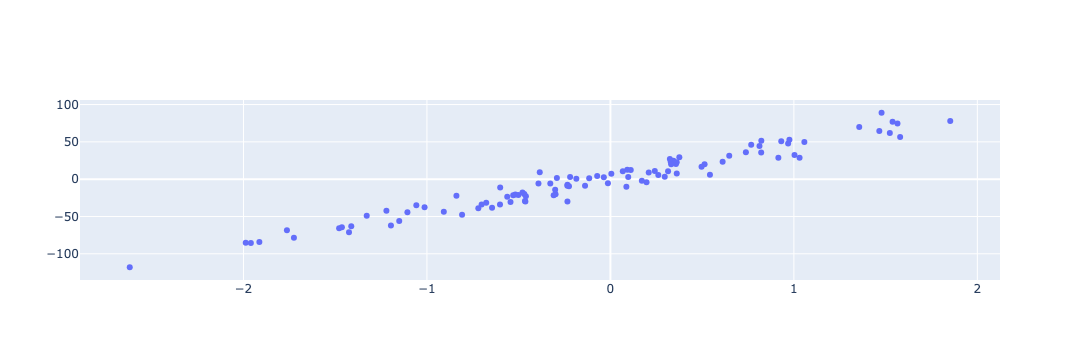

In [218]:
fig  = go.Figure()

fig.add_trace(go.Scatter(x=x[:,0], y=y, mode="markers", name="Data Points"))

In [219]:
x=x[:,0]

In [220]:
beta_1 = 2
beta_0 = 1
y_pred = x * beta_1 + beta_0

- bütün noktalara mesafeler mümkün mertebe en az olsun
  - mesafe -> y axis'e paralel is düşüm arasındaki mesafe -> absolute value square
  - ortalama


$min_{{\beta}_0, {\beta}1} {\frac{1}{N}{\sum_{i=1}^{N}{ (y_i - ({\beta}_1*x_i+{\beta}_0))^2}}}$

In [221]:
beta_1_samples = np.random.rand(100) * 100 - 50
beta_0_samples = np.random.rand(100) * 100 - 50

In [222]:
def loss_fn(y_true, y_pred) -> float:
    return np.mean( (y_true - y_pred)**2 )

In [223]:
min_loss = np.inf

best_param = None,None
for beta_0, beta_1 in zip(beta_0_samples, beta_1_samples):
    y_pred = x * beta_1 + beta_0

    if (l := loss_fn(y, y_pred) ) < min_loss:
        min_loss = l
        print(f"Beta 0 : {beta_0} Beta 1: {beta_1} {min_loss}")
        best_param = beta_0 ,beta_1

Beta 0 : 32.966911338010945 Beta 1: 47.092553796195915 1077.7030286457018
Beta 0 : 19.031021369283494 Beta 1: 27.927596177404652 684.0012643463665
Beta 0 : 15.378679261362464 Beta 1: 37.26055553245082 343.8748479494809
Beta 0 : 2.424765577910634 Beta 1: 49.194009561906014 97.11637397974877
Beta 0 : -0.003915077469244466 Beta 1: 43.64481497892048 79.74790390223751


In [224]:
best_param, min_loss

((np.float64(-0.003915077469244466), np.float64(43.64481497892048)),
 np.float64(79.74790390223751))

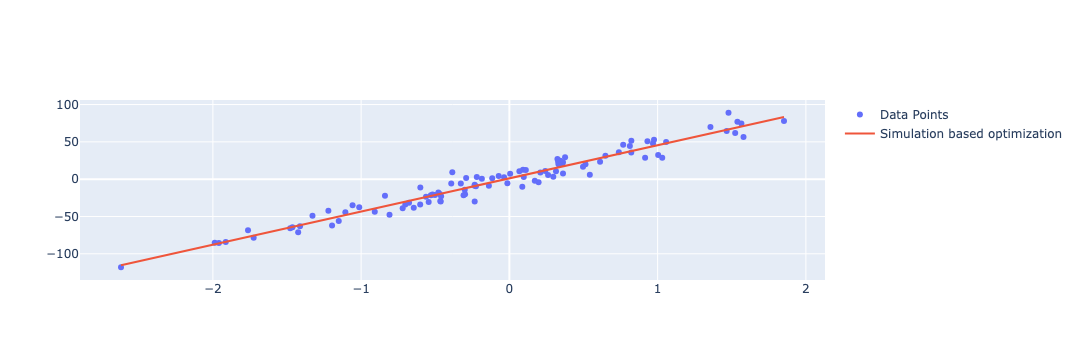

In [225]:
fig  = go.Figure()

beta_0 ,beta_1 = 1.16511048, 44.43715967
fig.add_trace(go.Scatter(x=x, y=y, mode="markers", name="Data Points"))
fig.add_trace(go.Scatter(x=x, y=beta_1  * x + beta_0, mode="lines", name="Simulation based optimization"))

In [226]:
beta_1_samples = np.random.rand(1000) * 400 - 200
beta_0_samples = np.random.rand(1000) * 400 - 200


losses = []
beta_0s = []
beta_1s = []

for beta_0, beta_1 in zip(beta_0_samples, beta_1_samples):
    y_pred = x * beta_1 + beta_0
    l = loss_fn(y, y_pred)

    losses.append(l)
    beta_0s.append(beta_0)
    beta_1s.append(beta_1)

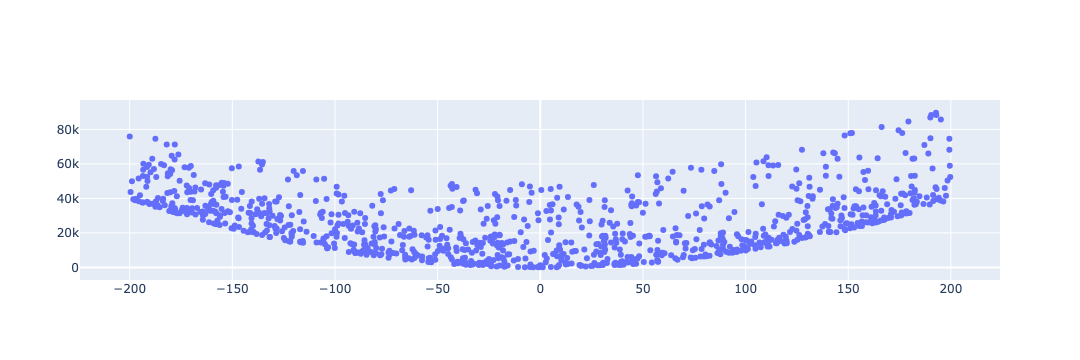

In [227]:
fig  = go.Figure()

fig.add_trace(go.Scatter(x=beta_0s, y=losses, mode="markers", name="Data Points"))

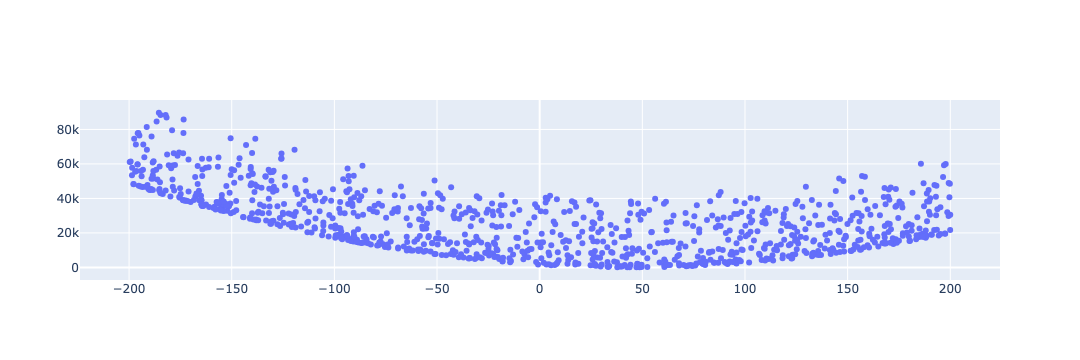

In [228]:
fig = go.Figure()

fig.add_trace(go.Scatter(x=beta_1s, y=losses, mode="markers", name="Data Points"))


$min_{{\beta}_0, {\beta}1} {\frac{1}{N}{\sum_{i=1}^{N}{ (y_i - ({\beta}_1*x_i+{\beta}_0))^2}}}$

$\frac{\partial}{\partial{\beta}_0}  = -{\frac{2}{N}{\sum_{i=1}^{N}{  (y_i - ({\beta}_1*x_i+{\beta}_0))}}}$

$\frac{\partial}{\partial{\beta}_1}  = -{\frac{2}{N}{\sum_{i=1}^{N}{ x_i (y_i - ({\beta}_1*x_i+{\beta}_0))}}}$

In [229]:
beta = np.random.random(2)
beta

array([0.242044  , 0.91660383])

In [230]:
y_pred = beta[0] + beta[1]  * x
y_pred

array([ 1.09565892,  0.32183168, -0.72745789,  0.53008431, -0.19716894,
        0.83571779, -0.18272643,  0.73935661,  0.80270883,  1.1618861 ,
        0.99540298,  1.65181421,  0.91892529,  0.04069191, -0.49902433,
        0.32615228, -1.55419714,  0.71250689,  1.18706211, -2.1592244 ,
        0.69733409,  0.33102565, -0.18484568,  1.08110509,  1.67620237,
        1.58546327, -0.30850372,  0.20920571, -0.30948259, -0.85440357,
        0.56937475,  0.58641024,  0.48132826, -0.24353623, -0.59025435,
        0.42248776, -0.03202728,  0.57352096,  0.99599182, -0.02532361,
        0.5733006 , -0.3784253 ,  1.638059  , -0.23300447,  0.02741812,
       -0.11736384, -0.0339488 , -0.34927524,  0.54337853,  0.43348917,
       -0.05829238,  0.24673101,  0.02743317,  1.59668734, -0.11092389,
        0.55700584,  0.54568133,  0.07186827,  0.02702053, -1.57976928,
        0.53910061,  0.03509658, -0.77202688, -0.40146056, -1.09941941,
        1.12990771, -1.33902229, -1.511676  , -0.2733509 ,  0.94

In [231]:
g_beta0 = - (y - y_pred).sum()
g_beta1 = - ( x * (y - y_pred) ).sum()

In [232]:
beta[0] -= 0.01 *g_beta0
beta[1] -= 0.01 *g_beta1

In [233]:
beta

array([-3.35434391, 36.82558439])

In [234]:
def lstsq(x,y, n_epoch:int = 100,early_stop:bool=True):
    beta = np.random.random(2)
    g_beta = np.zeros(2)

    for i in range(n_epoch):
        y_pred = beta[0] + beta[1] * x

        g_beta[0] = -(y - y_pred).sum()
        g_beta[1] = - (x * (y - y_pred) ).sum()

        print(f"Gradient norm epoch {i} {np.linalg.norm(g_beta) } {loss_fn(y, y_pred):.4f}")

        if np.linalg.norm(g_beta) < 0.01 and early_stop:
            break

        beta -= 0.01 * g_beta

    return beta
    
beta = lstsq(x,y)



Gradient norm epoch 0 3606.077179076586 1635.9961
Gradient norm epoch 1 692.2435328911521 139.3347
Gradient norm epoch 2 152.034454915781 81.0223
Gradient norm epoch 3 33.64749211386395 78.1997
Gradient norm epoch 4 7.449478420715035 78.0614
Gradient norm epoch 5 1.649327501543026 78.0546
Gradient norm epoch 6 0.36516430264686106 78.0543
Gradient norm epoch 7 0.08084808715151122 78.0543
Gradient norm epoch 8 0.017899923848326723 78.0543
Gradient norm epoch 9 0.00396307797876781 78.0543


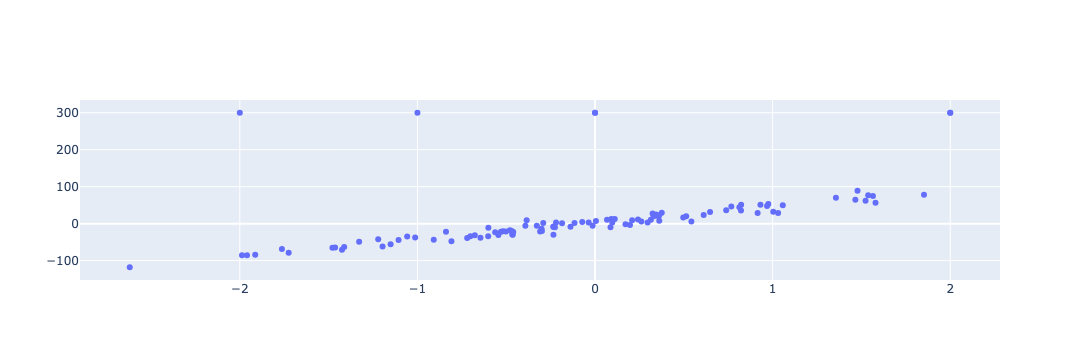

In [235]:
x, y = make_reg_data(anomaly=True)
x = x[:,0]

fig  = go.Figure()

fig.add_trace(go.Scatter(x=x, y=y, mode="markers", name="Data Points"))

Gradient norm epoch 0 4122.104762371156 6611.9661
Gradient norm epoch 1 408.07990916291135 4863.7167
Gradient norm epoch 2 40.49907489020696 4846.6270
Gradient norm epoch 3 4.032500215230409 4846.4592
Gradient norm epoch 4 0.4032564872613686 4846.4576
Gradient norm epoch 5 0.040551973103487605 4846.4575
Gradient norm epoch 6 0.004106779204191352 4846.4575


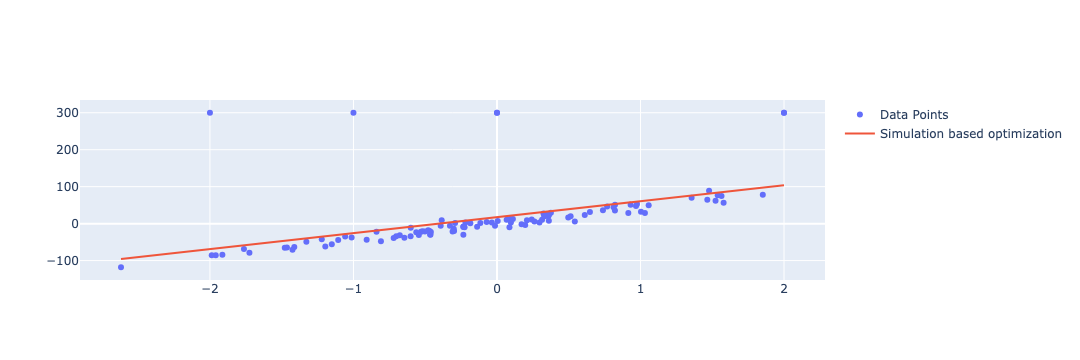

In [236]:
x, y = make_reg_data(anomaly=True)
x = x[:,0]

beta = lstsq(x,y)
fig = go.Figure()

fig.add_trace(go.Scatter(x=x, y=y, mode="markers", name="Data Points"))
fig.add_trace(go.Scatter(x=x, y=beta[1]  * x + beta[0], mode="lines", name="Simulation based optimization"))

$min_{{\beta}_0, {\beta}1} {\frac{1}{N}{\sum_{i=1}^{N}{ (y_i - ({\beta}_1*x_i+{\beta}_0))^2}}} + \lambda (|\beta_0| + |\beta_1|)$


$\frac{\partial}{\partial{\beta}_0}  = -{\frac{2}{N}{\sum_{i=1}^{N}{  (y_i - ({\beta}_1*x_i+{\beta}_0))}}} -/+ \lambda ? $

$\frac{\partial}{\partial{\beta}_1}  = -{\frac{2}{N}{\sum_{i=1}^{N}{ x_i (y_i - ({\beta}_1*x_i+{\beta}_0))}}} -/+ \lambda ? $


In [237]:
def l1_reg(x,y, n_epoch:int = 100, lamb: float=1.0, early_stop:bool=True):
    beta = np.random.random(2)
    g_beta = np.zeros(2)

    for i in range(n_epoch):
        y_pred = beta[0] + beta[1] * x


        if beta[0] > 0:
            g_beta[0] = -(y - y_pred).sum() + lamb
        else:
            g_beta[0] = -(y - y_pred).sum() - lamb

        if beta[1] > 0:
            g_beta[1] = - (x * (y - y_pred) ).sum() + lamb
        else:
            g_beta[1] = - (x * (y - y_pred) ).sum() - lamb

        print(f"Gradient norm epoch {i} {np.linalg.norm(g_beta) } {loss_fn(y, y_pred):.4f}")

        if np.linalg.norm(g_beta) < 0.01 and early_stop:
            break

        beta -= 0.01 * g_beta

    return beta
    
beta_l1 = l1_reg(x,y)
beta = lstsq(x,y)


beta_l1, beta


Gradient norm epoch 0 4140.928009868843 6628.0369
Gradient norm epoch 1 410.2145043852086 4864.0021
Gradient norm epoch 2 40.746920154120225 4846.6396
Gradient norm epoch 3 4.061918188813815 4846.4606
Gradient norm epoch 4 0.4068154323082708 4846.4579
Gradient norm epoch 5 0.040989040455029734 4846.4578
Gradient norm epoch 6 0.004161012627392587 4846.4578
Gradient norm epoch 0 4164.405589483127 6649.7452
Gradient norm epoch 1 411.9635490910962 4864.0647
Gradient norm epoch 2 40.84405966511488 4846.6301
Gradient norm epoch 3 4.061514567380205 4846.4592
Gradient norm epoch 4 0.40546130401530917 4846.4576
Gradient norm epoch 5 0.04068397846659342 4846.4575
Gradient norm epoch 6 0.004108797172718962 4846.4575


(array([17.53490422, 43.11859813]), array([17.54535209, 43.13006899]))

Gradient norm epoch 0 4146.100135638004 6635.5877
Gradient norm epoch 1 410.03266535697156 4864.0273
Gradient norm epoch 2 40.63662906419424 4846.6394
Gradient norm epoch 3 4.038771983974951 4846.4606
Gradient norm epoch 4 0.4029137171001371 4846.4579
Gradient norm epoch 5 0.04039249811626889 4846.4578
Gradient norm epoch 6 0.004074797425000088 4846.4578
Gradient norm epoch 0 2921.4214191402093 6623.6299
Gradient norm epoch 1 295.50645049669043 5145.6670
Gradient norm epoch 2 30.142775758040603 5059.8898
Gradient norm epoch 3 3.105578087277885 5054.0869
Gradient norm epoch 4 0.3236503421119326 5053.3085
Gradient norm epoch 5 0.034154997135780185 5053.2570
Gradient norm epoch 6 0.003651769306067357 5053.2491
Gradient norm epoch 0 4160.466857396771 6644.9589
Gradient norm epoch 1 411.8824497714103 4864.0396
Gradient norm epoch 2 40.87708454530122 4846.6301
Gradient norm epoch 3 4.070222276536766 4846.4592
Gradient norm epoch 4 0.40703964847297797 4846.4576
Gradient norm epoch 5 0.0409338

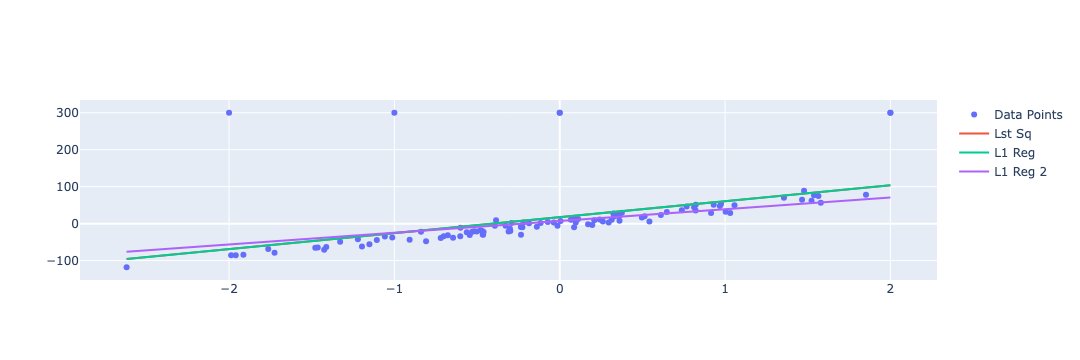

In [238]:
x, y = make_reg_data(anomaly=True)
x = x[:,0]

beta_l1 = l1_reg(x,y)
beta_l1_2 = l1_reg(x,y, lamb=1000.)

beta = lstsq(x,y)

print(beta_l1)
print(beta_l1_2)
print(beta)

fig = go.Figure()

fig.add_trace(go.Scatter(x=x, y=y, mode="markers", name="Data Points"))
fig.add_trace(go.Scatter(x=x, y=beta[1]  * x + beta[0], mode="lines", name="Lst Sq"))
fig.add_trace(go.Scatter(x=x, y=beta_l1[1]  * x + beta_l1[0], mode="lines", name="L1 Reg"))
fig.add_trace(go.Scatter(x=x, y=beta_l1_2[1]  * x + beta_l1_2[0], mode="lines", name="L1 Reg 2"))

$min_{{\beta}_0, {\beta}1} {\frac{1}{N}{\sum_{i=1}^{N}{ (y_i - ({\beta}_1*x_i+{\beta}_0))^2}}} + \lambda (\beta_0^2 + \beta_1^2)$


$\frac{\partial}{\partial{\beta}_0}  = -{\frac{2}{N}{\sum_{i=1}^{N}{  (y_i - ({\beta}_1*x_i+{\beta}_0))}}} +  2 \lambda \beta_0  $

$\frac{\partial}{\partial{\beta}_1}  = -{\frac{2}{N}{\sum_{i=1}^{N}{ x_i (y_i - ({\beta}_1*x_i+{\beta}_0))}}} +  2 \lambda \beta_1 $


In [239]:
def l2_reg(x,y, n_epoch:int = 100, lamb: float=1.0, early_stop:bool=True):
    beta = np.random.random(2)
    g_beta = np.zeros(2)

    for i in range(n_epoch):
        y_pred = beta[0] + beta[1] * x


        g_beta[0] = -(y - y_pred).sum() + 2 * lamb * beta[0]
        g_beta[1] = -(y - y_pred).sum() + 2 * lamb * beta[1]

        print(f"Gradient norm epoch {i} {np.linalg.norm(g_beta) } {loss_fn(y, y_pred):.4f}")

        if np.linalg.norm(g_beta) < 0.01 and early_stop:
            break

        beta -= 0.01 * g_beta

    return beta
    
beta_l2 = l2_reg(x,y)
beta = lstsq(x,y)


beta_l2, beta


Gradient norm epoch 0 2022.0066198208915 6683.0908
Gradient norm epoch 1 28.17268514557994 5583.6462
Gradient norm epoch 2 0.5796446713443301 5573.2603
Gradient norm epoch 3 0.22591451975236404 5573.0041
Gradient norm epoch 4 0.21739450740106894 5572.8895
Gradient norm epoch 5 0.2129915587596804 5572.7791
Gradient norm epoch 6 0.20873096528611307 5572.6709
Gradient norm epoch 7 0.2045563354255618 5572.5648
Gradient norm epoch 8 0.2004652085707611 5572.4610
Gradient norm epoch 9 0.1964559043970329 5572.3591
Gradient norm epoch 10 0.19252678630934042 5572.2594
Gradient norm epoch 11 0.1886762505832472 5572.1616
Gradient norm epoch 12 0.18490272557142684 5572.0658
Gradient norm epoch 13 0.18120467106002977 5571.9719
Gradient norm epoch 14 0.1775805776387056 5571.8799
Gradient norm epoch 15 0.17402896608611557 5571.7898
Gradient norm epoch 16 0.17054838676423958 5571.7014
Gradient norm epoch 17 0.16713741902886273 5571.6149
Gradient norm epoch 18 0.1637946706485951 5571.5300
Gradient norm 

(array([14.75339426, 14.73920849]), array([17.54535222, 43.13006866]))

Gradient norm epoch 0 4185.277391971674 6668.3615
Gradient norm epoch 1 414.17063647844424 4864.3669
Gradient norm epoch 2 41.08183566655256 4846.6430
Gradient norm epoch 3 4.087663930454909 4846.4607
Gradient norm epoch 4 0.40839955527885463 4846.4579
Gradient norm epoch 5 0.04102112657031269 4846.4578
Gradient norm epoch 6 0.004148220438707683 4846.4578
Gradient norm epoch 0 2048.2454643055457 6653.8930
Gradient norm epoch 1 27.592226105468885 5551.9354
Gradient norm epoch 2 0.7495303159529069 5542.2637
Gradient norm epoch 3 0.9827246523802077 5542.6244
Gradient norm epoch 4 0.9670935867705149 5543.1133
Gradient norm epoch 5 0.9478075084920965 5543.5946
Gradient norm epoch 6 0.9288521308833066 5544.0664
Gradient norm epoch 7 0.9102750989630611 5544.5289
Gradient norm epoch 8 0.8920695971322781 5544.9823
Gradient norm epoch 9 0.8742282051911441 5545.4267
Gradient norm epoch 10 0.8567436410876913 5545.8625
Gradient norm epoch 11 0.8396087682660315 5546.2896
Gradient norm epoch 12 0.822

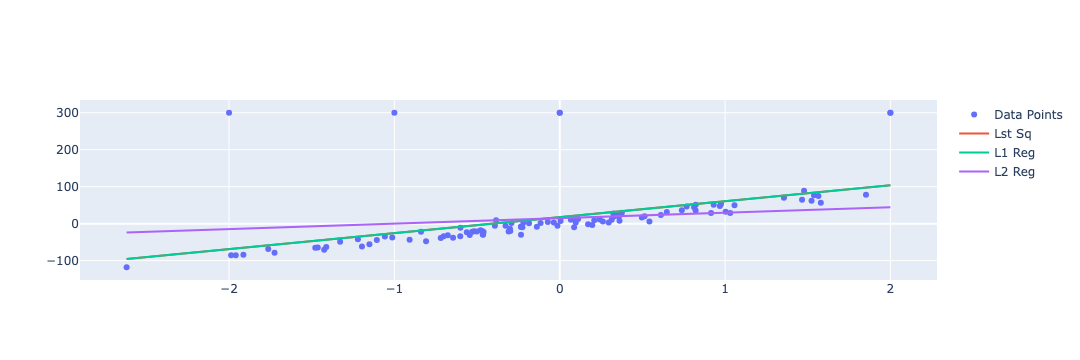

In [240]:
x, y = make_reg_data(anomaly=True)
x = x[:,0]

beta_l1 = l1_reg(x,y)
beta_l2 = l2_reg(x,y)
beta = lstsq(x,y)


print(beta_l2)
print(beta)

fig = go.Figure()

fig.add_trace(go.Scatter(x=x, y=y, mode="markers", name="Data Points"))
fig.add_trace(go.Scatter(x=x, y=beta[1]  * x + beta[0], mode="lines", name="Lst Sq"))
fig.add_trace(go.Scatter(x=x, y=beta_l1[1]  * x + beta_l1[0], mode="lines", name="L1 Reg"))
fig.add_trace(go.Scatter(x=x, y=beta_l2[1]  * x + beta_l2[0], mode="lines", name="L2 Reg"))

$min_{{\beta}_0, {\beta}1} {\frac{1}{N}{\sum_{i=1}^{N}{ (y_i - ({\beta}_1*x_i+{\beta}_0))^2}}} + \lambda_1 (|\beta_0| + |\beta_1|) + \lambda_2 (\beta_0^2 + \beta_1^2)$


$\frac{\partial}{\partial{\beta}_0}  = -{\frac{2}{N}{\sum_{i=1}^{N}{  (y_i - ({\beta}_1*x_i+{\beta}_0))}}} +  2 \lambda \beta_0  $

$\frac{\partial}{\partial{\beta}_1}  = -{\frac{2}{N}{\sum_{i=1}^{N}{ x_i (y_i - ({\beta}_1*x_i+{\beta}_0))}}} +  2 \lambda \beta_1 $


$y = \beta_0 + \beta_1  x_1^{x_2} \dots \beta_n x_n$ 

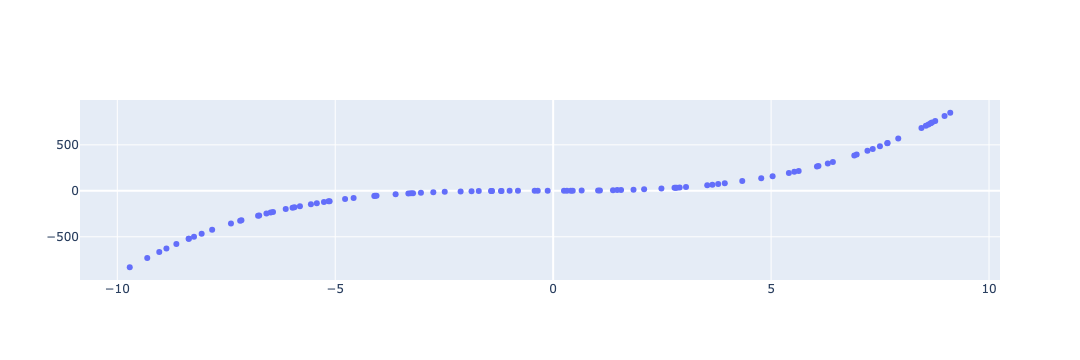

In [241]:
x = np.random.random(100) * -20 + 10

y = x**3 + x**2 + x + 1

fig = go.Figure()

fig.add_trace(go.Scatter(x=x, y=y, mode="markers", name="Data Points"))

$z = x^3$

$w = x^2$

$min_{{\beta}_0, {\beta}1, {\beta}_2, {\beta}_3} {\frac{1}{N}{\sum_{i=1}^{N}{ (y_i - ({\beta}_3 x_i^3+{\beta}_2 x_i^2+{\beta}_1 x_i+{\beta}_0))^2}}}$

$\frac{\partial}{\partial{\beta}_0}  = -{\frac{2}{N}{\sum_{i=1}^{N}{  (y_i - ({\beta}_1*x_i+{\beta}_0))}}}$

$\frac{\partial}{\partial{\beta}_1}  = -{\frac{2}{N}{\sum_{i=1}^{N}{ x_i (y_i - ({\beta}_1*x_i+{\beta}_0))}}}$

In [262]:
def lstsq(x,y, n_epoch:int = 100,early_stop:bool=True):
    beta = np.random.random(4)
    g_beta = np.zeros(4)

    for i in range(n_epoch):
        y_pred = beta[0] + beta[1] * x + beta[2] * x*x + beta[3] * x * x * x

        g_beta[0] = -(y - y_pred).mean()
        g_beta[1] = - (x * (y - y_pred)).mean()
        g_beta[2] = - (x * x * (y - y_pred) ).mean()
        g_beta[3] = - (x * x * x * (y - y_pred) ).mean()

        print(f"Gradient norm epoch {i} {g_beta } {loss_fn(y, y_pred):.4f}")

        if np.linalg.norm(g_beta) < 0.01 and early_stop:
            break

        beta -= 0.0000002 * g_beta

    return beta
    
beta = lstsq(x,y,n_epoch=10_000)



Gradient norm epoch 0 [   -41.65941329   -341.04138365  -2588.47944142 -24117.16841731] 6110.3839
Gradient norm epoch 1 [   -41.43991491   -331.16451164  -2569.81749399 -23435.80487573] 5878.2984
Gradient norm epoch 2 [   -41.22623609   -321.56623011  -2551.66053072 -22773.65170506] 5659.0310
Gradient norm epoch 3 [   -41.01821289   -312.23868466  -2533.99432272 -22130.16730329] 5451.8694
Gradient norm epoch 4 [   -40.81568602   -303.1742423   -2516.80504227 -21504.82533793] 5256.1406
Gradient norm epoch 5 [   -40.61850064   -294.36548528  -2500.0792515  -20897.11431546] 5071.2092
Gradient norm epoch 6 [   -40.42650633   -285.80520496  -2483.80389139 -20306.53716302] 4896.4749
Gradient norm epoch 7 [   -40.23955685   -277.48639594  -2467.96627107 -19732.6108218 ] 4731.3709
Gradient norm epoch 8 [   -40.05751014   -269.40225031  -2452.55405748 -19174.86585199] 4575.3619
Gradient norm epoch 9 [   -39.8802281    -261.54615211  -2437.55526528 -18632.84604877] 4427.9425
Gradient norm epoch 

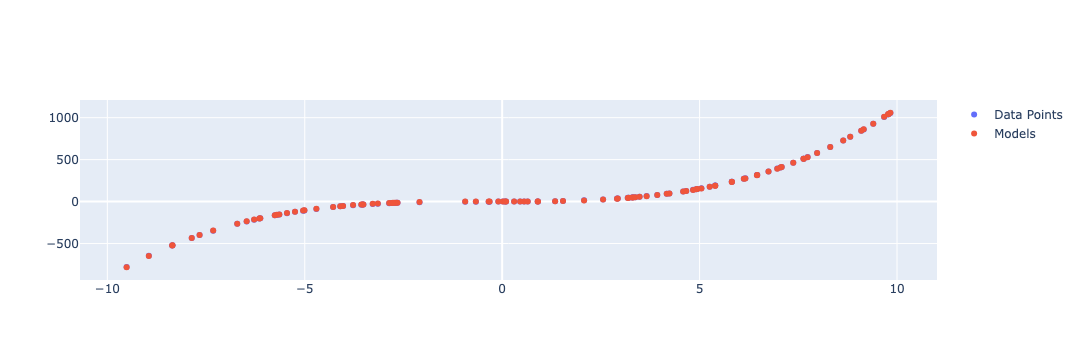

In [267]:
x = np.random.random(100) * -20 + 10

y = x**3 + x**2 + x + 1

y_pred = beta[3] * x**3 +  beta[2] * x**2 + beta[1] * x + beta[0]

fig = go.Figure()

fig.add_trace(go.Scatter(x=x, y=y, mode="markers", name="Data Points"))
fig.add_trace(go.Scatter(x=x, y=y_pred, mode="markers", name="Models"))

